# Entrega Final Laboratorio de implementación 2




## Librerías

In [1]:
#Import de librerias basicas tablas y matrices
import numpy as np
import pandas as pd

#Gradient Boosting
import lightgbm as lgb

#Funciones auxiliares sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold #Split y cross Validation
from sklearn.metrics import cohen_kappa_score, accuracy_score, balanced_accuracy_score #Metricas
from sklearn.utils import shuffle

#Visualizacióon
from plotly import express as px

#Plot de matriz de confusion normalizada en actuals
from utils import plot_confusion_matrix

import os

#Optimizacion de hiperparametros
import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

#Guardado de objetos en archivos joblib
from joblib import load, dump

# Para análisis de texto
import re


c:\Users\FBorbiconi\anaconda3\envs\ldi2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Paths del repo

In [2]:

#Subimos dos niveles para quedar en la carpeta que contiene input y UA_MDM_Labo2
BASE_DIR = '../'

#Datos de entrenamiento
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")

#Salida de modelos entrenados
PATH_TO_MODELS = os.path.join(BASE_DIR, "work/models")

#Artefactos a subir a optuna
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")

#Artefactos que optuna gestiona
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")


SEED = 20001101 #Semilla de procesos aleatorios (para poder replicar exactamente al volver a correr un modelo)
TEST_SIZE = 0.2 #Facción para train/test= split

## Lectura de los datasets

In [3]:
# Datos Tabulares
dataset = pd.read_csv(PATH_TO_TRAIN)

## Datos tabulares

### Feature engineering manual

In [4]:
### Se crea la variable Has_name
# Lista de nombres genéricos que NO consideramos verdaderos nombres
nombres_invalidos = ['Unnamed', 'No name', 'No Name Yet', 'Urgent', 'Lost Dog']

# Rellenamos nulos
dataset['Name'] = dataset['Name'].fillna('Unnamed')

# Identificamos si contienen dígitos
contiene_numeros = dataset['Name'].str.contains(r'\d', regex=True)

# Extension del nombre
extension = (dataset['Name'].str.len() <= 3) | (dataset['Name'].str.len() > 15)

# Creamos la columna Has_name: 1 si no es inválido y no contiene números
dataset['Has_name'] = (~dataset['Name'].isin(nombres_invalidos) & ~contiene_numeros & ~extension).astype(int)

### Largo de la descripcion
dataset['Description_length'] = dataset['Description'].str.len()

### Score de salud
dataset['Cuidado_Medico'] = (
    (dataset['Vaccinated'] == 1).astype(int) +
    (dataset['Dewormed'] == 1).astype(int) +
    (dataset['Sterilized'] == 1).astype(int)
)

### Edad
def clasificar_edad(age):
    if age <= 6:
        return 1  # Cachorro
    elif age > 72:
        return 4 # Adulto Mayor
    elif age > 24:
        return 3  # Adulto
    else:
        return 2  # Normal

dataset['Age_group'] = dataset['Age'].apply(clasificar_edad)


### Raza
dataset['Raza_pura'] = np.where(
    (dataset['Breed1'] != 307) & (dataset['Breed2'] == 0), 1, 0
)

### Cantidad de mascotas a adoptar
def clasificar_cantidad(q):
    if q == 1:
        return 0
    elif q <= 3:
        return 1
    elif q <= 6:  # Cambiado a <= 6 para incluir hasta 6
        return 2
    else:
        return 3

dataset['Cant_Adopcion'] = dataset['Quantity'].apply(clasificar_cantidad)

### Color
dataset['color_count'] = (
    (dataset['Color1'] != 0).astype(int) +
    (dataset['Color2'] != 0).astype(int) +
    (dataset['Color3'] != 0).astype(int)
)

### Adopcion gratuita
dataset['gratis'] = (dataset['Fee'] == 0).astype(int)

### Genero y castracion
dataset['Is_female_intact'] = (dataset['Gender'] == 2) & (dataset['Sterilized'] == 2)
dataset['Is_male_intact'] = (dataset['Gender'] == 1) & (dataset['Sterilized'] == 2)


### RescuerID repetidos
dataset['Rescuer_repetido'] = dataset.duplicated('RescuerID', keep=False).astype(int)

### Gato y Perro segun genero
dataset['Dog_male'] = ((dataset['Type'] == 1) & (dataset['Gender'] == 1)).astype(int)
dataset['Cat_male'] = ((dataset['Type'] == 2) & (dataset['Gender'] == 1)).astype(int)

### Hay videos
dataset['Video'] = (dataset['VideoAmt'] > 1).astype(int)

### Cantidad de fotos
def clasificar_fotos(x):
    if x == 0:
        return 0
    elif x <= 5:
        return 1
    else:
        return 2

dataset['Fotos'] = dataset['PhotoAmt'].apply(clasificar_fotos)

### Indica si la descripción contiene una palabra "linda"
# Lista de palabras clave (en minúsculas)
palabras_lindas = [
    'love', 'loving', 'sweet', 'friendly', 'cute', 'adorable',
    'affectionate', 'gentle', 'cuddly', 'playful', 'happy', 'kind',
    'compassionate', 'endearing', 'charming', 'delightful', 'joyful', 'precious']

# Expresión regular que detecta si alguna palabra está presente
patron = r'\b(' + '|'.join(palabras_lindas) + r')\b'

# Crear variable binaria
dataset['Descripcion_linda'] = dataset['Description'].str.lower().str.contains(patron, flags=re.IGNORECASE, na=False).astype(int)


### Combinacion de colores
def sorted_color_combo(row):
    colores = sorted([row['Color1'], row['Color2'], row['Color3']])
    return int(''.join(map(str, colores)))

dataset['Color_combo'] = dataset.apply(sorted_color_combo, axis=1)

C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_26800\949666915.py:106: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  dataset['Descripcion_linda'] = dataset['Description'].str.lower().str.contains(patron, flags=re.IGNORECASE, na=False).astype(int)


In [5]:
df_final = dataset

### Feature Engineering con Random Forest

#### Opción one-hot encoding

In [6]:
""" import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = dataset.drop(columns=['Description', 'RescuerID', 'PetID', 'Name', 'AdoptionSpeed'])
y = dataset['AdoptionSpeed']

# Parámetros
n_modelos = 20       # cantidad de Random Forests
n_arboles = 1       # árboles por modelo
n_hojas = 16        # Hojas por arbol

# Copia del DataFrame original
df_final = X.copy()

# Entrenar y agregar columnas
for i in range(1, n_modelos + 1):
    rf = RandomForestClassifier(
        n_estimators=n_arboles,
        max_leaf_nodes= n_hojas,
        random_state=i
    )
    rf.fit(X, y)
    
    # Obtener la hoja final de cada observación
    leaf_ids = rf.apply(X).ravel()  # Devuelve un ID de hoja por fila

    # Obtener los IDs únicos de hojas (puede ser menos de 16 si no se usan todas)
    unique_leaves = sorted(set(leaf_ids))

    # DataFrame con columnas 0/1 por hoja
    leaf_df = pd.DataFrame(
        {f"R{i}L_{j+1}": (leaf_ids == leaf).astype(int)
            for j, leaf in enumerate(unique_leaves)},
        index=X.index
    )
        
    # Agregar al DataFrame final
    df_final = pd.concat([df_final, leaf_df], axis=1)

# Ahora df_final contiene las variables originales + las columnas RFxLy se le suma la clase
df_final = pd.concat([df_final, y], axis=1)
df_final.head() """

' import pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\n\nX = dataset.drop(columns=[\'Description\', \'RescuerID\', \'PetID\', \'Name\', \'AdoptionSpeed\'])\ny = dataset[\'AdoptionSpeed\']\n\n# Parámetros\nn_modelos = 20       # cantidad de Random Forests\nn_arboles = 1       # árboles por modelo\nn_hojas = 16        # Hojas por arbol\n\n# Copia del DataFrame original\ndf_final = X.copy()\n\n# Entrenar y agregar columnas\nfor i in range(1, n_modelos + 1):\n    rf = RandomForestClassifier(\n        n_estimators=n_arboles,\n        max_leaf_nodes= n_hojas,\n        random_state=i\n    )\n    rf.fit(X, y)\n\n    # Obtener la hoja final de cada observación\n    leaf_ids = rf.apply(X).ravel()  # Devuelve un ID de hoja por fila\n\n    # Obtener los IDs únicos de hojas (puede ser menos de 16 si no se usan todas)\n    unique_leaves = sorted(set(leaf_ids))\n\n    # DataFrame con columnas 0/1 por hoja\n    leaf_df = pd.DataFrame(\n        {f"R{i}L_{j+1}": (leaf_ids == leaf).a

#### Opción leaf_id

In [7]:
""" import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = dataset.drop(columns=['Description', 'RescuerID', 'PetID', 'Name', 'AdoptionSpeed'])
y = dataset['AdoptionSpeed']

# Parámetros
n_modelos = 50       # cantidad de Random Forests
n_arboles = 1       # árboles por modelo
n_hojas = 16        # Hojas por arbol

# Copia del DataFrame original
df_final = X.copy()

# Entrenar y agregar columnas
for i in range(1, n_modelos + 1):
    rf = RandomForestClassifier(
        n_estimators=n_arboles,
        max_leaf_nodes= n_hojas,
        random_state=i
    )
    rf.fit(X, y)
    
    # Obtener la hoja final de cada observación
    leaf_ids = rf.apply(X).ravel()  # Devuelve un ID de hoja por fila

    # Crear nombres de columnas según formato RF{i}L{j}
    colnames = [f"RF{i}"]
    
    # Convertir a DataFrame
    leaf_df = pd.DataFrame(leaf_ids, columns=colnames, index=X.index)
        
    # Agregar al DataFrame final
    df_final = pd.concat([df_final, leaf_df], axis=1)

# Ahora df_final contiene las variables originales + las columnas RFxLy le sumo la clase
df_final = pd.concat([df_final, y], axis=1)
df_final.head() """

' import pandas as pd\nfrom sklearn.ensemble import RandomForestClassifier\n\nX = dataset.drop(columns=[\'Description\', \'RescuerID\', \'PetID\', \'Name\', \'AdoptionSpeed\'])\ny = dataset[\'AdoptionSpeed\']\n\n# Parámetros\nn_modelos = 50       # cantidad de Random Forests\nn_arboles = 1       # árboles por modelo\nn_hojas = 16        # Hojas por arbol\n\n# Copia del DataFrame original\ndf_final = X.copy()\n\n# Entrenar y agregar columnas\nfor i in range(1, n_modelos + 1):\n    rf = RandomForestClassifier(\n        n_estimators=n_arboles,\n        max_leaf_nodes= n_hojas,\n        random_state=i\n    )\n    rf.fit(X, y)\n\n    # Obtener la hoja final de cada observación\n    leaf_ids = rf.apply(X).ravel()  # Devuelve un ID de hoja por fila\n\n    # Crear nombres de columnas según formato RF{i}L{j}\n    colnames = [f"RF{i}"]\n\n    # Convertir a DataFrame\n    leaf_df = pd.DataFrame(leaf_ids, columns=colnames, index=X.index)\n\n    # Agregar al DataFrame final\n    df_final = pd.conca

### Selección de variables y división en Train y Test

In [8]:
# Features menos estas variables

var_to_remove = ['Description', 'RescuerID', 'PetID', 'Name', 'AdoptionSpeed']

features = [f for f in df_final.columns if f not in var_to_remove]

label = 'AdoptionSpeed'


In [9]:
#Separo un 20% para test estratificado opr target
train, test = train_test_split(df_final,
                               test_size = TEST_SIZE,
                               random_state = SEED,
                               stratify = df_final.AdoptionSpeed)

In [10]:
#Genero dataframes de train y test con sus respectivos targets
X_train = train[features]
y_train = train[label]

X_test = test[features]
y_test = test[label]

### Búsqueda mejores hiperparámetros


In [11]:
#Genero una metrica para que lightGBM haga la evaluación y pueda hacer early_stopping en el cross validation
def lgb_custom_metric_kappa(dy_pred, dy_true):
    metric_name = 'kappa'
    value = cohen_kappa_score(dy_true.get_label(),dy_pred.argmax(axis=1),weights = 'quadratic')
    is_higher_better = True
    return(metric_name, value, is_higher_better)

#Funcion objetivo a optimizar. En este caso vamos a hacer 5fold cv sobre el conjunto de train.
# El score de CV es el objetivo a optimizar. Ademas vamos a usar los 5 modelos del CV para estimar el conjunto de test,
# registraremos en optuna las predicciones, matriz de confusion y el score en test.
# CV Score -> Se usa para determinar el rendimiento de los hiperparametros con precision
# Test Score -> Nos permite testear que esta todo OK, no use (ni debo usar) esos datos para nada en el entrenamiento
# o la optimizacion de hiperparametros

def cv_es_lgb_objective(trial):

    #PArametros para LightGBM
    lgb_params = {
                        #PArametros fijos
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique()),
                        #Hiperparametros a optimizar utilizando suggest_float o suggest_int segun el tipo de dato
                        #Se indica el nombre del parametro, valor minimo, valor maximo
                        #en elgunos casos el parametro log=True para parametros que requieren buscar en esa escala
                        'lambda_l1': trial.suggest_float('lambda_l1', 1e-8, 10.0, log=True),
                        'lambda_l2': trial.suggest_float('lambda_l2', 1e-8, 10.0, log=True),
                        'num_leaves': trial.suggest_int('num_leaves', 2, 256),
                        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
                        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
                        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
                        'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                        'learning_rate': trial.suggest_float('learning_rate', 0.003, 0.1, log=True),
                        'n_estimators':5000
                        }

    #Voy a generar estimaciones de los 5 modelos del CV sobre los datos test y los acumulo en la matriz scores_ensemble
    scores_ensemble = np.zeros((len(y_test),len(y_train.unique())))

    #Score del 5 fold CV inicializado en 0
    score_folds = 0

    #Numero de splits del CV
    n_splits = 5

    #Objeto para hacer el split estratificado de CV
    skf = StratifiedKFold(n_splits=n_splits)

    for i, (if_index, oof_index) in enumerate(skf.split(X_train, y_train)):

        #Dataset in fold (donde entreno)
        lgb_if_dataset = lgb.Dataset(data=X_train.iloc[if_index],
                                        label=y_train.iloc[if_index],
                                        free_raw_data=False)

        #Dataset Out of fold (donde mido la performance del CV)
        lgb_oof_dataset = lgb.Dataset(data=X_train.iloc[oof_index],
                                        label=y_train.iloc[oof_index],
                                        free_raw_data=False)

        #Entreno el modelo
        lgb_model = lgb.train(lgb_params,
                                lgb_if_dataset,
                                valid_sets=lgb_oof_dataset,
                                callbacks=[lgb.early_stopping(10, verbose=False)],
                                feval = lgb_custom_metric_kappa
                                )

        #Acumulo los scores (probabilidades) de cada clase para cada uno de los modelos que determino en los folds
        #Se predice el 20% de los datos que separe para tes y no uso para entrenar en ningun fold
        scores_ensemble = scores_ensemble + lgb_model.predict(X_test)

        #Score del fold (registros de dataset train que en este fold quedan out of fold)
        score_folds = score_folds + cohen_kappa_score(y_train.iloc[oof_index],
                                                            lgb_model.predict(X_train.iloc[oof_index]).argmax(axis=1),weights = 'quadratic')/n_splits


    #Guardo prediccion del trial sobre el conjunto de test
    # Genero nombre de archivo
    predicted_filename = os.path.join(PATH_TO_TEMP_FILES,f'test_{trial.study.study_name}_{trial.number}.joblib')
    # Copia del dataset para guardar la prediccion
    predicted_df = test.copy()
    # Genero columna pred con predicciones sumadas de los 5 folds
    predicted_df['pred'] = [scores_ensemble[p,:] for p in range(scores_ensemble.shape[0])]
    # Grabo dataframe en temp_artifacts
    dump(predicted_df, predicted_filename)
    # Indico a optuna que asocie el archivo generado al trial
    upload_artifact(trial, predicted_filename, artifact_store)

    #Grabo natriz de confusion
    #Nombre de archivo
    cm_filename = os.path.join(PATH_TO_TEMP_FILES,f'cm_{trial.study.study_name}_{trial.number}.jpg')
    fi_filename = os.path.join(PATH_TO_TEMP_FILES,f'fi_{trial.study.study_name}_{trial.number}.png')
    #Grabo archivo
    plot_confusion_matrix(y_test,scores_ensemble.argmax(axis=1)).write_image(cm_filename)
    # feature importance
    ax = lgb.plot_importance(lgb_model, importance_type="gain", figsize=(10, 7))
    ax.figure.savefig(fi_filename)
    #Asocio al trial
    upload_artifact(trial, cm_filename, artifact_store)
    upload_artifact(trial, fi_filename, artifact_store)

    #Determino score en conjunto de test y asocio como metrica adicional en optuna
    test_score = cohen_kappa_score(y_test,scores_ensemble.argmax(axis=1),weights = 'quadratic')
    trial.set_user_attr("test_score", test_score)

    #Devuelvo score del 5fold cv a optuna para que optimice en base a eso
    return(score_folds)

[I 2025-08-22 16:10:25,050] Using an existing study with name '3 - FE Manual' instead of creating a new one.
C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_26800\2604798757.py:88: FutureWarning: upload_artifact() got {'study_or_trial', 'file_path', 'artifact_store'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['study_or_trial', 'file_path', 'artifact_store'] in upload_artifact() have been deprecated since v4.0.0. They will be replaced with the corresponding keyword arguments in v6.0.0, so please use the keyword specification instead. See https://github.com/optuna/optuna/releases/tag/v4.0.0 for details.
  upload_artifact(trial, predicted_filename, artifact_store)
C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_26800\2604798757.py:100: FutureWarning:

upload_artifact() got {'study_or_trial', 'file_path', 'artifact_store'} as positional arguments but they were expected to be given as keyword arguments.
Positional arguments ['stu

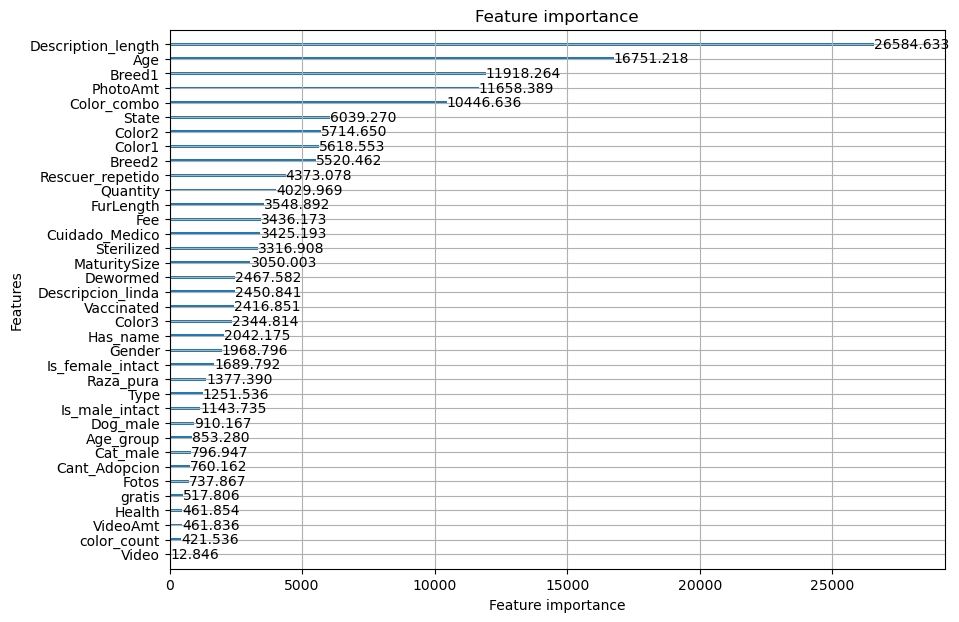

In [12]:
#Inicio el store de artefactos (archivos) de optuna
artifact_store = FileSystemArtifactStore(base_path=PATH_TO_OPTUNA_ARTIFACTS)

#Genero estudio
study = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name="3 - FE Manual",
                            load_if_exists = True)
#Corro la optimizacion
study.optimize(cv_es_lgb_objective, n_trials=1)

### Modelo Final

In [15]:
#Vamos a replicar el resultado de la optimizacion reentrenando el modelo con el mejor conjunto de hiperparametros
#Generamos parametros incluyendo los fijos y la mejor solución que encontro optuna
lgb_params =  {      
                        'objective': 'multiclass',
                        'verbosity':-1,
                        'num_class': len(y_train.unique())} | study.best_params

lgb_train_dataset = lgb.Dataset(data=X_train,
                                label=y_train)


#Entreno
lgb_model = lgb.train(lgb_params,
                    lgb_train_dataset)

#Muestro matriz de confusion y kappa
display(plot_confusion_matrix(y_test,lgb_model.predict(X_test).argmax(axis=1)))

cohen_kappa_score(y_test,lgb_model.predict(X_test).argmax(axis=1),
                             weights = 'quadratic')

0.3740154957595392

## Datos imágenes

### Librerías

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, cohen_kappa_score
import os
import shutil
import time
import copy
import datetime
from tqdm import tqdm

import optuna
from optuna.artifacts import FileSystemArtifactStore, upload_artifact

import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.autograd import Variable
import torch.nn.functional as F

from joblib import load, dump

from utils import plot_confusion_matrix
# Verificamos que CUDA está funcional
torch.cuda.is_available()

False

### Modelo preentrenado (ResNet50)

In [16]:
# Importo modelo ResNet entrenado en Imagenet
resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
# Modificar la última capa para adaptarse a tu problema específico
num_ftrs = resnet50.fc.in_features
resnet50.fc = torch.nn.Linear(num_ftrs, 5) # Clasificación 5 clases
# Configuro para usar cuda si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet50 = resnet50.to(device)
# Instancio del criterio de pérdida CrossEntropyLoss
criterion = nn.CrossEntropyLoss()


### Path

In [17]:
# Paths
BASE_DIR = '../'
PATH_TO_TRAIN = os.path.join(BASE_DIR, "input/petfinder-adoption-prediction/train/train.csv")
PATH_TO_IMAGES_DIR = os.path.join("C:/Users/", "FBorbiconi/OneDrive - Universidad Austral/Documentos/MCD/Laboratorio de implementación 2/Dataset/train_images")
PATH_TO_TEMP_FILES = os.path.join(BASE_DIR, "work/optuna_temp_artifacts")
PATH_TO_OPTUNA_ARTIFACTS = os.path.join(BASE_DIR, "work/optuna_artifacts")

MODEL_NAME = '04 ResNet'

MODEL_VERSION = '1.0.0'

# Parametros y variables
CREATE_PYTORCH_DIRECTORIES = 1
SEED = 20001101
BATCH_SIZE = 50
TEST_SIZE = 0.2
IMAGE_SIZE = 299
CPU_CORES = os.cpu_count()

# Armo el nuevo directorio de train
new_train_directory = os.path.join(BASE_DIR, 'work/train_images_classes')
os.makedirs(new_train_directory, exist_ok=True) # si ya existe el nombre, lo deja como está

# Armo el nuevo directorio de validación
new_val_directory = os.path.join(BASE_DIR, 'work/val_images_classes')
os.makedirs(new_val_directory, exist_ok=True)

# Definir las clases ordenadas
class_names = ['0', '1', '2', '3', '4']

# Mapear las etiquetas de las clases a números enteros consecutivos
class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

# Creo las carpetas de clases dentro de los directorios
for clase in class_names: # Una para cada clase
   os.makedirs(os.path.join(new_train_directory, str(clase)), exist_ok=True)
   os.makedirs(os.path.join(new_val_directory, str(clase)), exist_ok=True)


### Carga y Preprocesamiento

In [18]:
def visualize_pet(pet_id):
    path_to_image = os.path.join(PATH_TO_IMAGES_DIR, f'{pet_id}-1.jpg') # Irá a la primera imagen de la mascota
    # Cargar la imagen
    image_to_show = cv2.imread(path_to_image)
    # Convertir a formato RGB
    image_to_show = cv2.cvtColor(image_to_show, cv2.COLOR_BGR2RGB)
    # Visualizar la imagen
    plt.imshow(image_to_show)
    plt.axis('off')  # No mostrar los ejes
    plt.show()

def visualize_image(image):
    # Convierte la imagen a un formato de enteros (CV_8U)
    image = cv2.convertScaleAbs(image)
    image= cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    # Visualizar la imagen
    plt.imshow(image.astype(np.uint8))
    plt.axis('off')  # No mostrar los ejes
    plt.show()

In [19]:

if CREATE_PYTORCH_DIRECTORIES == 1: # Poner en 0 si ya tengo las carpetas train_images_classes y val_images_classes con las imágenes copiadas
    # Función para copiar las imágenes a los directorios correspondientes
    def copy_imag(data, directorio_destino):
        for index, row in data.iterrows():
            petID = row['PetID']
            adoption_speed = row['AdoptionSpeed']
            
            # Nombre del archivo de imagen
            nombre_archivo = f"{petID}-1.jpg"
            
            # Ruta completa de la imagen de origen
            ruta_origen = os.path.join(PATH_TO_IMAGES_DIR, nombre_archivo)
            
            # Ruta completa del directorio de destino
            ruta_destino = os.path.join(directorio_destino, str(adoption_speed), nombre_archivo)
            
            # Verificar si el archivo de origen existe
            if os.path.exists(ruta_origen):
                # Copiar el archivo de origen al directorio de destino
                shutil.copy2(ruta_origen, ruta_destino)
        print("Completada la copia a: ",str(directorio_destino))

    # Copiar las imágenes al directorio de train
    copy_imag(train, new_train_directory)

    # Copiar las imágenes al directorio de val
    copy_imag(test, new_val_directory)

    print("Proceso completado.")

Completada la copia a:  ../work/train_images_classes
Completada la copia a:  ../work/val_images_classes
Proceso completado.


In [20]:
# Genero los DataLoaders
def create_dataloaders(train_directory, val_directory, batch_size, num_workers):
    # Transformaciones de imagen para el conjunto de entrenamiento
    train_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.RandomHorizontalFlip(),
        # GaussianBlur con 50% de probabilidad
        transforms.RandomApply(
            [transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))],
            p=0.5
        ),
        # ColorJitter con 50% de probabilidad
        transforms.RandomApply(
            [transforms.ColorJitter(brightness=0.2, contrast=0.2,
                                    saturation=0.2, hue=0.05)],
            p=0.5
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Transformaciones de imagen para el conjunto de validación (sin data augment)
    val_transforms = transforms.Compose([
        transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # Crear conjuntos de datos para el conjunto de entrenamiento y validación
    conjunto_entrenamiento = datasets.ImageFolder(train_directory, transform=train_transforms)
    conjunto_validacion = datasets.ImageFolder(val_directory, transform=val_transforms)

    # Asignar las clases ordenadas al conjunto de datos
    conjunto_entrenamiento.class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}
    conjunto_validacion.class_to_idx = {class_name: i for i, class_name in enumerate(class_names)}

    # Crear dataloaders para el conjunto de entrenamiento y validación
    train_dataloader = torch.utils.data.DataLoader(conjunto_entrenamiento, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    val_dataloader = torch.utils.data.DataLoader(conjunto_validacion, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return train_dataloader, val_dataloader

# Aplico las funcion de los DataLoaders
train_dataloader, val_dataloader = create_dataloaders(new_train_directory , new_val_directory , BATCH_SIZE, CPU_CORES)

In [21]:
#Genero una lista de PetIDs con imagen en el orden en que aparecen en el data loader
test_sample_ids = [i[0].split('/')[-1].split('-')[0] for i in val_dataloader.dataset.samples]

### Entrenamiento

In [ ]:
def train_val(model, criterion, dataloaders, datasets, device, num_epochs=2, lr=0.001, momentum = 0.9 ,trial=None):
    
    # Instancio Stochastic Gradient Descent (SGD): Defino el parámetro del Learning Rate (define "el paso" en que avanzan los pesos en cada iteración) y el Momentum (pone innercia a la dirección del gradiente descendiente para que no cambie de dirección en minimos locales)
    optimizer = optim.SGD(resnet50.parameters(), lr=lr, momentum=momentum) # Parámetros default del SGD
    
    #Inicializo variables
    since = time.time()


    #Inicializo variable de mejor kappa entre trials
    try:
        #Intento obtener el mejor kappa de optuna
        previous_best = study.best_value
    except:
        #Si no hay, seteo -999
        previous_best = -999

    #Inicializo variables de mejor modelo y mejor accuracy y mejor kappa de este trial
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    best_kappa =  -999


    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs - 1))
        print('-' * 10)
        
        #Inicializo listas de kappa true y predicted y scores para esta epoch
        epoch_kappa_labels_true = []
        epoch_kappa_labels_predicted = []
        epoch_output_scores = []

        #Cada epoch tiene una fase de entrenamiento y validación
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
            else:
                model.eval()   # Set model to evaluate mode

            #Inicializo variables de loss y accuracy para esta fase de epoch
            epoch_phase_running_loss = 0.0
            epoch_phase_running_corrects = 0

            # Itero sobre los datos.
            for inputs, labels in tqdm(dataloaders[phase]):
                inputs = inputs.to(device)
                labels = labels.to(device)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward
                # Track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                    elif phase == 'val':
                        #Agrego los valores de kappa true y predicted para cada batch en validación
                        epoch_kappa_labels_true.extend(labels.cpu().numpy().tolist())
                        epoch_kappa_labels_predicted.extend(preds.cpu().numpy().tolist())
                        outputs_np = outputs.cpu().numpy()
                        epoch_output_scores.extend([outputs_np[i,:] for i in range(outputs_np.shape[0])])

                # Statistics for each phase
                epoch_phase_running_loss += loss.item() * inputs.size(0)
                epoch_phase_running_corrects += torch.sum(preds == labels.data)
                
                #END OF BATCH

            epoch_loss = epoch_phase_running_loss / len(datasets[phase])
            epoch_acc = epoch_phase_running_corrects.double() / len(datasets[phase])
            
            #Calculo el kappa para cada epoch
            if phase == 'train':
                #overall_train_losses.append(epoch_loss)
                current_kappa_score = np.nan
            else:
                #overall_val_losses.append(epoch_loss)
                current_kappa_score = cohen_kappa_score(epoch_kappa_labels_true,
                                  epoch_kappa_labels_predicted,
                                  weights = 'quadratic')
                    


            print(f'{phase.title()} Loss: {epoch_loss:.4f} Acc: {epoch_acc*100:.2f}% Kappa: {current_kappa_score:.3f}')

            # If this is the best Epoch so far -> Deep copy the model
            if phase == 'val' and current_kappa_score > best_kappa:
                best_acc = epoch_acc
                best_kappa = current_kappa_score
                best_model_wts = copy.deepcopy(model.state_dict())


                #Best Epoch within a trial and better than previous trials
                if trial is not None and best_kappa > previous_best:

                    #Save test dataset with predictions
                    predicted_filename = os.path.join(PATH_TO_TEMP_FILES,f'test_{trial.study.study_name}_{trial.number}.joblib')
                    predicted_df = pd.DataFrame({'PetID':test_sample_ids,
                                'pred':epoch_output_scores}).merge(val_data, on='PetID')
                    dump(predicted_df, predicted_filename)

                    #Generate and save CM 
                    cm_filename = os.path.join(PATH_TO_TEMP_FILES,f'cm_{trial.study.study_name}_{trial.number}.jpg')
                    plot_confusion_matrix(epoch_kappa_labels_true,epoch_kappa_labels_predicted).write_image(cm_filename)

            #END OF PHASE

        #END OF EPOCH

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(
        time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:.2f}%'.format(best_acc * 100))

    # Load best model weights
    model.load_state_dict(best_model_wts)

    # Save in optuna trial the best test dataset, cm and model weights
    if trial is not None and best_kappa > previous_best:
        upload_artifact(trial, predicted_filename, artifact_store)   

        upload_artifact(trial, cm_filename, artifact_store)

        file_name = f'{MODEL_NAME}_{MODEL_VERSION}_{trial.number}.pth'
        model_path = os.path.join(PATH_TO_TEMP_FILES, file_name)
        torch.save(model, model_path) # Podemos guardar solo los pesos si queremos: best_model.state_dict()
        upload_artifact(trial, model_path, artifact_store)

    return model,best_kappa

best_model,_ = train_val(resnet50, criterion, 
                       dataloaders={'train': train_dataloader, 
                                    'val': val_dataloader}, 
                       datasets={'train': train, 'val': test}, 
                       device=device, 
                       num_epochs=40)
# Guardo el modelo
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
file_name = f'{MODEL_NAME}_{MODEL_VERSION}_{run_id}.pth'
model_path = os.path.join(PATH_TO_TEMP_FILES, file_name)
torch.save(best_model, model_path) # Podemos guardar solo los pesos si queremos: best_model.state_dict()
print(f'Modelo guardado en {model_path}')

Epoch 0/3
----------


100%|██████████| 235/235 [1:36:20<00:00, 24.60s/it]


Train Loss: 1.4208 Acc: 30.75% Kappa: nan


100%|██████████| 59/59 [10:27<00:00, 10.64s/it]  


Val Loss: 1.3883 Acc: 32.61% Kappa: 0.190
Epoch 1/3
----------


...

Val Loss: 1.3597 Acc: 35.58% Kappa: 0.260
Epoch 3/3
----------


100%|██████████| 235/235 [1:47:35<00:00, 27.47s/it]


Train Loss: 1.3397 Acc: 37.24% Kappa: nan


100%|██████████| 59/59 [08:57<00:00,  9.11s/it] 


Val Loss: 1.3535 Acc: 35.85% Kappa: 0.285
Training complete in 449m 19s
Best val Acc: 35.85%
Modelo guardado en ../work/optuna_temp_artifacts\04 ResNet_1.0.0_20250816_174213.pth


### Entrenamiento con Optuna

In [ ]:
wartifact_store = FileSystemArtifactStore(base_path=PATH_TO_OPTUNA_ARTIFACTS)


def optuna_train(trial):

    epochs = trial.suggest_int('epochs', 5, 5)

    lr = trial.suggest_float('lr', 0.00001, 0.1, log=True)

    momentum = trial.suggest_float('momentum', 0.0, 0.95)

    _,best_score = train_val(resnet50, criterion,
                       dataloaders={'train': train_dataloader, 
                                    'val': val_dataloader}, 
                       datasets={'train': train_data, 'val': val_data}, 
                       device=device, 
                       num_epochs=epochs,
                       lr=lr,
                       momentum = momentum,
                       trial=trial)


    return(best_score)

In [ ]:
study = optuna.create_study(direction='maximize',
                            storage="sqlite:///../work/db.sqlite3",  # Specify the storage URL here.
                            study_name=f'{MODEL_NAME}_{MODEL_VERSION}',
                            load_if_exists = True)
study.optimize(optuna_train, n_trials=30)

### Predicción Imágenes

In [22]:
Modelo = torch.load("C:/Users/FBorbiconi/OneDrive - Universidad Austral/Documentos/MCD/Laboratorio de implementación 2/Repo de github/UA_MDM_Labo2/work/optuna_temp_artifacts/04 ResNet_1.0.0_20250822_042321.pth")

C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_26800\2991137823.py:1: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



In [23]:
Modelo.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [25]:
import torch
import torch.nn.functional as F

all_preds = []
all_labels = []
all_probabilities = []

with torch.no_grad():  
    for images, labels in val_dataloader:  
        outputs = Modelo(images)  # forward pass (these are the logits)
        
        # Apply softmax to get probabilities
        probabilities = F.softmax(outputs, dim=1)
        
        # Get the predicted class (the one with the highest probability)
        _, preds = torch.max(probabilities, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probabilities.extend(probabilities.cpu().numpy())


In [26]:
len(all_preds)

2924

In [27]:
#Muestro matriz de confusion y kappa
display(plot_confusion_matrix(all_labels,all_preds))

cohen_kappa_score(all_labels,all_preds,
                             weights = 'quadratic')

0.2549932287887203

## Combinación de Resultados

In [28]:
# Dataset con resultados
Resultados = test[["PetID", "AdoptionSpeed"]]

# Sumamos la clase predicha por los datos tabulares
Resultados["Pred_DT"] = lgb_model.predict(X_test).argmax(axis=1)

# Sumamos las probabilidades predichas por los tabulares
df_pred = pd.DataFrame(lgb_model.predict(X_test), columns=[f"DT_Clase_{i}" for i in range(5)])
df_pred["PetID"] = test["PetID"].values

Resultados = pd.merge(Resultados, df_pred, on = "PetID", how="inner")

# Se crea un data frame con los resultados de las imágenes
pred_Im = pd.DataFrame({
    "PetID" : [s[-9:] for s in test_sample_ids],
    "Im_Pred" : all_preds,
    "Im_Clase_0" : [p[0] for p in all_probabilities],
    "Im_Clase_1" : [p[1] for p in all_probabilities],
    "Im_Clase_2" : [p[2] for p in all_probabilities],
    "Im_Clase_3" : [p[3] for p in all_probabilities],
    "Im_Clase_4" : [p[4] for p in all_probabilities]
})

#Sumamos esas predicciones al dataset Resultados
Resultados = pd.merge(Resultados, pred_Im, on = "PetID", how="left")


C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_26800\1549435372.py:5: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [29]:
# Calcular los promedios y crear 5 nuevas columnas
for i in range(5):
    Resultados[f'Promedio_Clase_{i}'] = (Resultados[f'DT_Clase_{i}'] + Resultados[f'Im_Clase_{i}']) / 2

# Realizar la prediccion con las 5 columnas promedio
columnas_promedio = [f'Promedio_Clase_{i}' for i in range(5)]

Resultados['Pred_Promedio'] = Resultados[columnas_promedio].idxmax(axis=1)

# A los que no son NA se los convierte a número
Resultados.loc[Resultados['Pred_Promedio'].notna(), 'Pred_Promedio'] = Resultados.loc[Resultados['Pred_Promedio'].notna(), 'Pred_Promedio'].str.split('_').str.get(-1).astype(int)

# A los que son NA porque no está la predicción de la imagen se les asigna la predicción de DT
Resultados.loc[Resultados['Pred_Promedio'].isna(), 'Pred_Promedio'] = Resultados.loc[Resultados['Pred_Promedio'].isna(), 'Pred_DT']
Resultados['Pred_Promedio'] = Resultados['Pred_Promedio'].astype('int64')
# Mostrar el DataFrame final con las nuevas columnas ---
Resultados

C:\Users\FBorbiconi\AppData\Local\Temp\ipykernel_26800\3673304729.py:8: FutureWarning:

The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError



,PetID,AdoptionSpeed,Pred_DT,DT_Clase_0,DT_Clase_1,DT_Clase_2,DT_Clase_3,DT_Clase_4,Im_Pred,Im_Clase_0,Im_Clase_1,Im_Clase_2,Im_Clase_3,Im_Clase_4,Promedio_Clase_0,Promedio_Clase_1,Promedio_Clase_2,Promedio_Clase_3,Promedio_Clase_4,Pred_Promedio
0,06bfadf29,4,4,0.009124,0.081341,0.169860,0.174403,0.565273,2.0,0.024110,0.234547,0.294049,0.204838,0.242456,0.016617,0.157944,0.231954,0.189620,0.403864,4
1,00b23513e,2,2,0.021981,0.235060,0.508009,0.182919,0.052030,2.0,0.030186,0.221475,0.267642,0.256066,0.224631,0.026083,0.228268,0.387826,0.219492,0.138331,2
2,40c0fdccb,4,2,0.007493,0.204661,0.396001,0.166453,0.225392,4.0,0.007678,0.094968,0.202413,0.303432,0.391510,0.007585,0.149815,0.299207,0.234942,0.308451,4
3,e748f52b7,2,2,0.033248,0.085074,0.455159,0.331701,0.094818,4.0,0.034971,0.127158,0.222886,0.223964,0.391022,0.034109,0.106116,0.339023,0.277832,0.242920,2
4,e0e604fc2,1,2,0.016078,0.298526,0.312880,0.225508,0.147007,4.0,0.028838,0.202136,0.242866,0.220815,0.305345,0.022458,0.250331,0.277873,0.223162,0.226176,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2994,48c598ef0,1,1,0.010539,0.429463,0.380695,0.147112,0.032192,1.0,0.065403,0.344234,0.297588,0.164803,0.127973,0.037971,0.386848,0.339141,0.155957,0.080082,1
2995,aa6b8a52b,2,1,0.005183,0.350513,0.287999,0.269348,0.086958,2.0,0.024415,0.212273,0.344671,0.220413,0.198228,0.014799,0.281393,0.316335,0.244880,0.142593,2
2996,2bbca459e,4,4,0.015577,0.285067,0.156604,0.070985,0.471766,2.0,0.018678,0.235516,0.294798,0.259399,0.191609,0.017128,0.260292,0.225701,0.165192,0.331687,4
2997,6cb5e1b06,1,1,0.004577,0.455665,0.285366,0.152536,0.101856,4.0,0.037938,0.236675,0.278472,0.166189,0.280726,0.021258,0.346170,0.281919,0.159362,0.191291,1


In [30]:
#Muestro matriz de confusion y kappa
display(plot_confusion_matrix(Resultados["AdoptionSpeed"].values, Resultados["Pred_Promedio"].values))

cohen_kappa_score(Resultados["AdoptionSpeed"].values, Resultados["Pred_Promedio"].values,
                             weights = 'quadratic')

0.39571440336076313